In [1]:
b = 0.001      # sediment burial rate (yr^-1)
c = 0.00115    # runoff coefficient (yr^-1)
h = 0.15       # outflow rate (yr^-1)
s = 0.7        # sedimentation rate (yr^-1)
r = 0.019      # max recycling rate (yr^-1)
m = 2.4        # half-saturation phosphorus density (g m^-2)
q = 8

F_intensive = 31.6
H_intensive = 18.6

W_pre = 0.147
W_post = 1.55

In [2]:
import numpy as np
from scipy.integrate import solve_ivp

# -------------------------
# Parameters
# -------------------------
b = 0.001
c = 0.00115
h = 0.15
s = 0.7
r = 0.019
m = 2.4
q = 8

F_intensive = 31.6
H_intensive = 18.6

W_pre = 0.147
W_post = 1.55


def recycling(P):
    return P**q / (m**q + P**q)


def rhs(t, y, forcing):
    U, P, M = y

    W, F, H = forcing(t)

    rec = r * M * recycling(P)

    dU = W + F - H - c * U
    dP = c * U - (s + h) * P + rec
    dM = s * P - b * M - rec

    return [dU, dP, dM]

In [3]:
from scipy.optimize import root_scalar

def f(P):
    return P**q / (m**q + P**q)

def equilibrium_equation(P, L):
    return (
        L
        - (s + h) * P
        + (r * s * P * f(P)) / (b + r * f(P))
    )


def compute_equilibria(L, Pmax=100):

    roots = []

    grid = np.logspace(-6, np.log10(Pmax), 2000)

    vals = equilibrium_equation(grid, L)

    for i in range(len(grid)-1):
        if vals[i] * vals[i+1] < 0:

            sol = root_scalar(
                equilibrium_equation,
                args=(L,),
                bracket=[grid[i], grid[i+1]]
            )

            roots.append(sol.root)

    return np.array(roots)

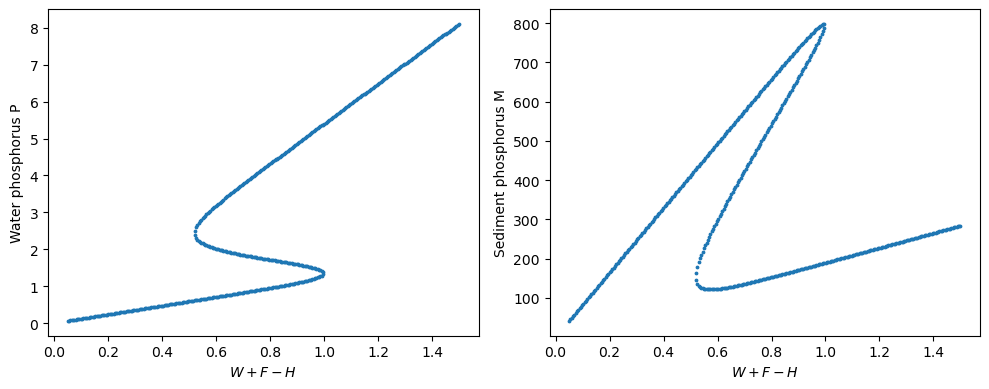

In [4]:
import matplotlib.pyplot as plt

L_values = np.linspace(0.05, 1.5, 300)

P_eq = []
M_eq = []

for L in L_values:

    roots = compute_equilibria(L)

    for P in roots:

        fp = f(P)

        M = s*P/(b + r*fp)

        P_eq.append([L, P])
        M_eq.append([L, M])

P_eq = np.array(P_eq)
M_eq = np.array(M_eq)

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].scatter(P_eq[:,0], P_eq[:,1], s=3)
ax[0].set_xlabel(r"$W+F-H$")
ax[0].set_ylabel("Water phosphorus P")

ax[1].scatter(M_eq[:,0], M_eq[:,1], s=3)
ax[1].set_xlabel(r"$W+F-H$")
ax[1].set_ylabel("Sediment phosphorus M")

plt.tight_layout()
plt.show()

In [5]:
def forcing_sim1(t):

    if t < 100:
        return W_pre, 0.0, 0.0

    elif t < 200:
        return W_post, 0.0, 0.0

    elif t < 250:
        return W_post, F_intensive, H_intensive

    else:
        return W_post, H_intensive, H_intensive

In [6]:
def forcing_sim2(t):

    if t < 100:
        return W_pre, 0.0, 0.0

    elif t < 200:
        return W_post, 0.0, 0.0

    elif t < 250:
        return W_post, F_intensive, H_intensive

    else:
        return W_pre, H_intensive, H_intensive

In [7]:
y0 = [0.0, 0.01, 0.01]

t_eval = np.linspace(0, 5000, 20000)

sol1 = solve_ivp(
    lambda t,y: rhs(t,y,forcing_sim1),
    [0,5000],
    y0,
    t_eval=t_eval
)

sol2 = solve_ivp(
    lambda t,y: rhs(t,y,forcing_sim2),
    [0,5000],
    y0,
    t_eval=t_eval
)

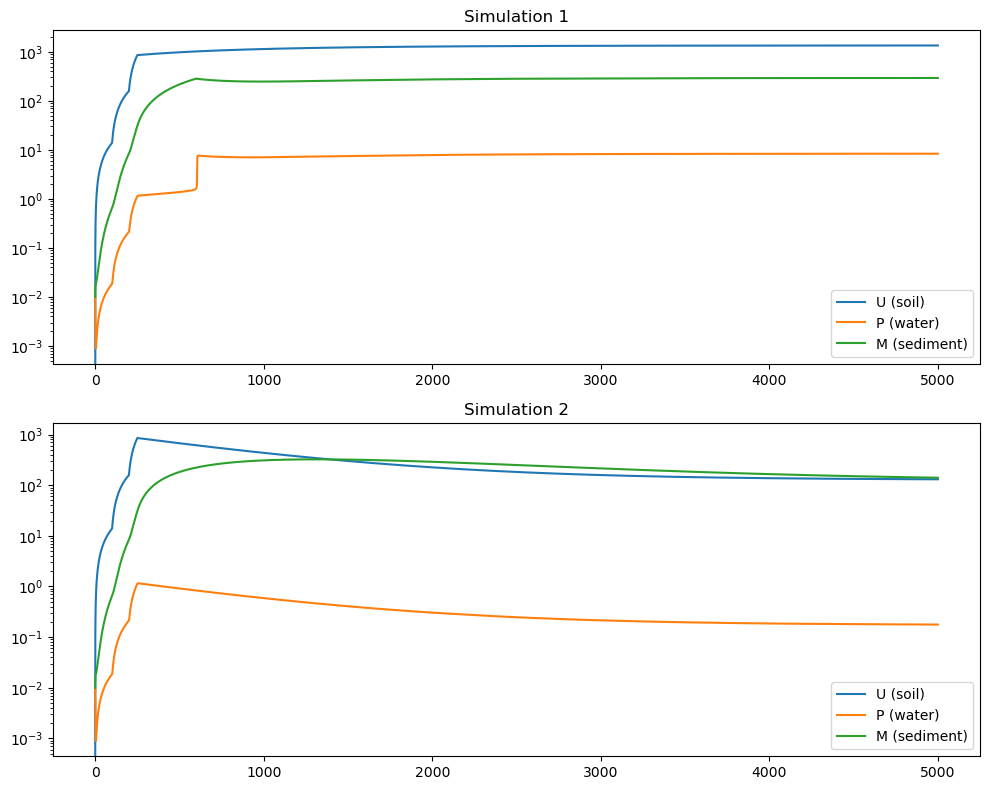

In [8]:
fig, ax = plt.subplots(2,1, figsize=(10,8))

for sol, axis, title in [
    (sol1, ax[0], "Simulation 1"),
    (sol2, ax[1], "Simulation 2")
]:

    axis.semilogy(sol.t, sol.y[0], label="U (soil)")
    axis.semilogy(sol.t, sol.y[1], label="P (water)")
    axis.semilogy(sol.t, sol.y[2], label="M (sediment)")

    axis.set_title(title)
    axis.legend()

plt.tight_layout()
plt.show()